In [13]:
import pandas as pd

In [14]:
import numpy as np


In [15]:
states = [
    "Lagos","Ogun","Oyo","Osun","Ondo","Ekiti",
    "Rivers","Bayelsa","Delta","Akwa Ibom","Cross River","Edo",
    "Enugu","Anambra","Imo","Abia","Ebonyi",
    "Kano","Kaduna","Katsina","Sokoto","Zamfara","Kebbi","Jigawa",
    "Borno","Yobe","Adamawa","Taraba","Gombe","Bauchi",
    "FCT","Niger","Kwara","Kogi","Benue","Plateau","Nasarawa"
]

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]


In [16]:
region_map = {
    "Lagos":"South West","Ogun":"South West","Oyo":"South West","Osun":"South West","Ondo":"South West","Ekiti":"South West",
    "Rivers":"South South","Bayelsa":"South South","Delta":"South South","Akwa Ibom":"South South","Cross River":"South South","Edo":"South South",
    "Enugu":"South East","Anambra":"South East","Imo":"South East","Abia":"South East","Ebonyi":"South East",
    "Kano":"North West","Kaduna":"North West","Katsina":"North West","Sokoto":"North West","Zamfara":"North West","Kebbi":"North West","Jigawa":"North West",
    "Borno":"North East","Yobe":"North East","Adamawa":"North East","Taraba":"North East","Gombe":"North East","Bauchi":"North East",
    "FCT":"North Central","Niger":"North Central","Kwara":"North Central","Kogi":"North Central","Benue":"North Central","Plateau":"North Central","Nasarawa":"North Central"
}

In [17]:
data = []

for state in states:
    for month in months:
        
        # Simulate rainfall pattern (seasonal logic)
        if month in ["Jun","Jul","Aug","Sep"]:
            base_rain = np.random.randint(180, 350)
        elif month in ["Apr","May","Oct"]:
            base_rain = np.random.randint(80, 180)
        else:
            base_rain = np.random.randint(0, 80)
        
        # Adjust by region (south wetter than north)
        if "South" in region_map[state]:
            rainfall = base_rain + np.random.randint(20, 80)
            humidity = np.random.randint(75, 95)
            temp = np.random.randint(25, 30)
        else:
            rainfall = base_rain - np.random.randint(10, 50)
            humidity = np.random.randint(30, 70)
            temp = np.random.randint(28, 36)
        
        rainfall = max(rainfall, 0)

        data.append([
            state,
            month,
            rainfall,
            temp,
            humidity,
            region_map[state]
        ])


In [18]:
df = pd.DataFrame(data, columns=[
    "State","Month","Rainfall_mm","Temperature_C","Humidity","Region"
])


In [19]:
df.to_csv("nigeria_rainfall_full.csv", index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [20]:
df.head()
df.shape

(444, 6)

In [21]:
import pandas as pd
import matplotlib.pyplot as plt


In [23]:
df = pd.read_csv("nigeria_rainfall_full.csv")


In [24]:
print("Shape:", df.shape)
print(df.head())

Shape: (444, 6)
   State Month  Rainfall_mm  Temperature_C  Humidity      Region
0  Lagos   Jan           90             27        85  South West
1  Lagos   Feb           98             28        92  South West
2  Lagos   Mar           63             29        82  South West
3  Lagos   Apr          220             25        94  South West
4  Lagos   May          106             26        84  South West


In [25]:
df['Rainfall_mm'] = pd.to_numeric(df['Rainfall_mm'], errors='coerce')


In [26]:
# Flood Risk Classification
def classify_risk(rainfall):
    if rainfall < 100:
        return "Low"
    elif rainfall <= 200:
        return "Medium"
    else:
        return "High"

df['Flood_Risk'] = df['Rainfall_mm'].apply(classify_risk)


In [27]:
##Average Rainfall by State
state_rainfall = df.groupby('State')['Rainfall_mm'].mean().sort_values(ascending=False)


In [28]:
##Monthly Rainfall Trend
monthly_rainfall = df.groupby('Month')['Rainfall_mm'].mean()


In [29]:
##Fix month order
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_rainfall = monthly_rainfall.reindex(month_order)

In [30]:
##Flood Risk Distribution
risk_dist = df['Flood_Risk'].value_counts()

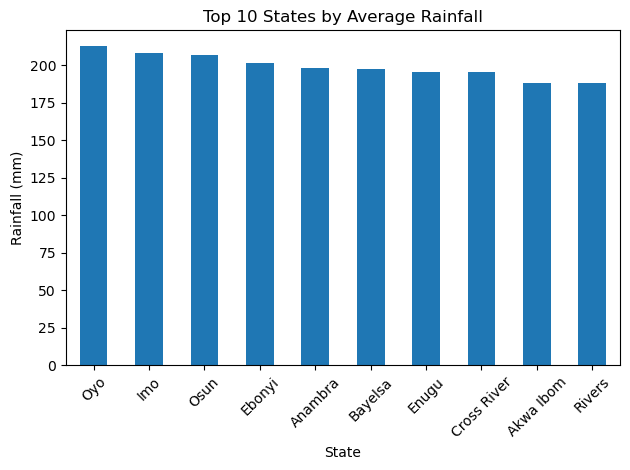

In [34]:
## Rainfall by State
plt.figure()
state_rainfall.head(10).plot(kind='bar')
plt.title("Top 10 States by Average Rainfall")
plt.xlabel("State")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("rainfall_by_state.png")
plt.show()


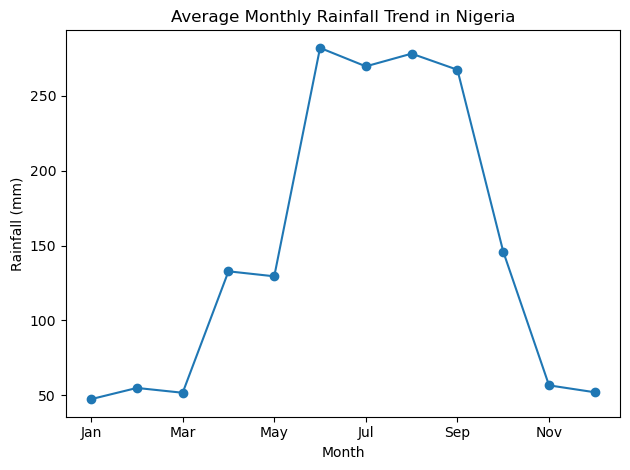

In [35]:
##Monthly Trend
plt.figure()
monthly_rainfall.plot(marker='o')
plt.title("Average Monthly Rainfall Trend in Nigeria")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.savefig("monthly_trend.png")
plt.show()


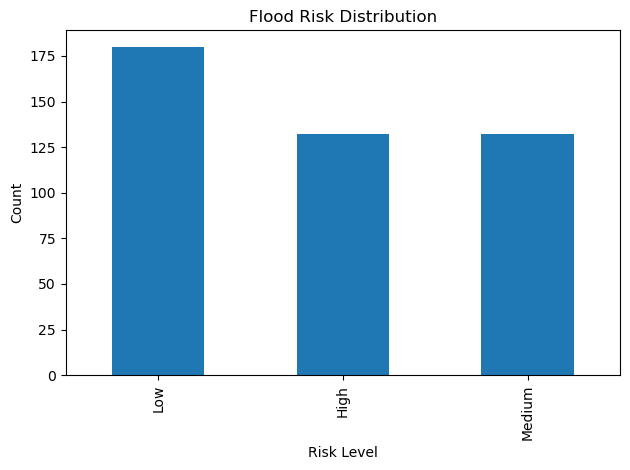

In [36]:
## Risk Distribution
plt.figure()
risk_dist.plot(kind='bar')
plt.title("Flood Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("flood_risk.png")
plt.show()

In [37]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


C:\Users\DELL\AppData\Local\Temp\ipykernel_8776\25751174.py:7: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


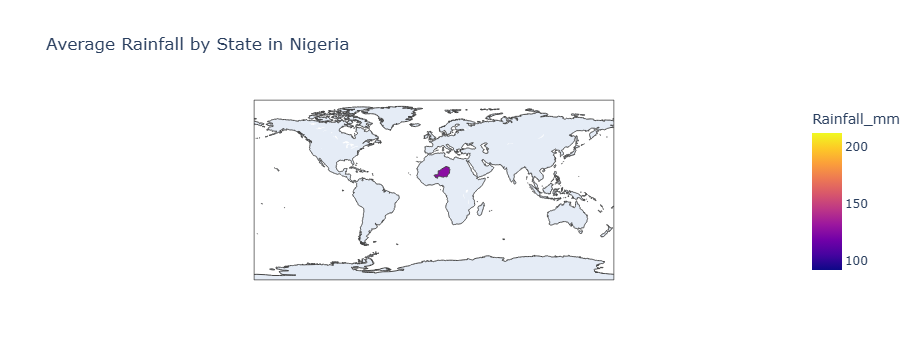

In [38]:
import plotly.express as px

# Average rainfall per state
state_avg = df.groupby('State')['Rainfall_mm'].mean().reset_index()

# Create map
fig = px.choropleth(
    state_avg,
    locations="State",
    locationmode="country names",
    color="Rainfall_mm",
    title="Average Rainfall by State in Nigeria",
)

fig.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_8776\3776062896.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



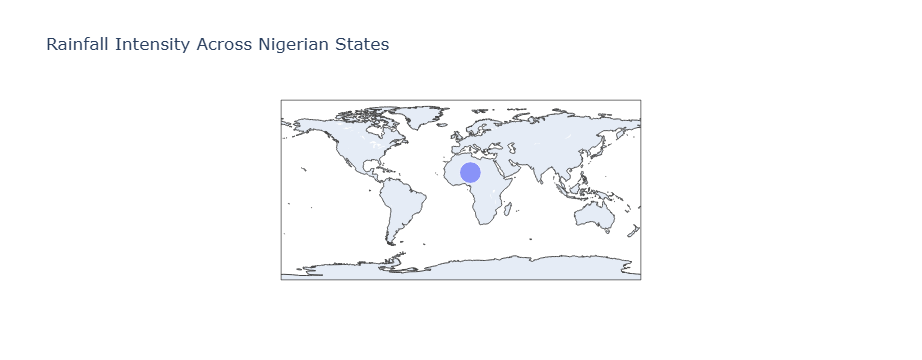

In [39]:
fig = px.scatter_geo(
    state_avg,
    locations="State",
    locationmode="country names",
    size="Rainfall_mm",
    title="Rainfall Intensity Across Nigerian States"
)

fig.show()


In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Flood_Risk_Encoded'] = le.fit_transform(df['Flood_Risk'])


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[['Rainfall_mm', 'Humidity', 'Temperature_C']]
y = df['Flood_Risk_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 1.0


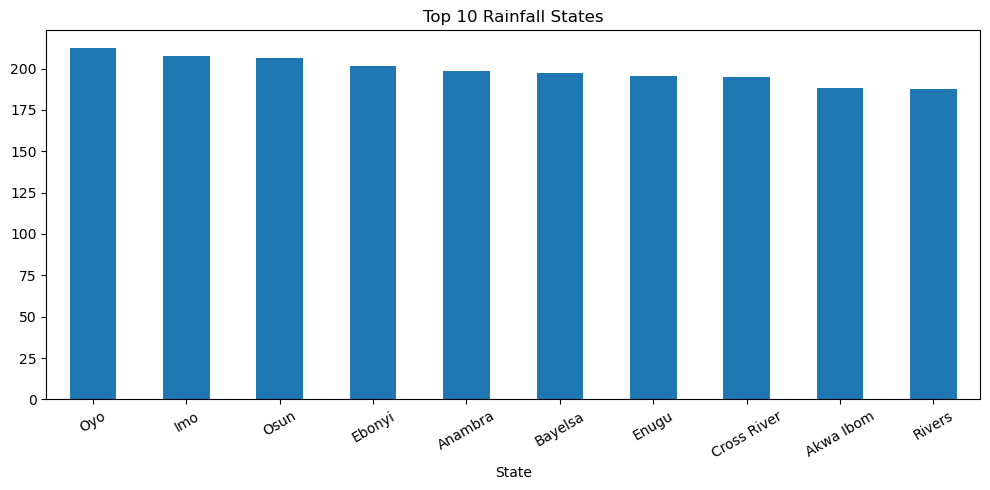

In [43]:
plt.figure(figsize=(10,5))
state_rainfall.head(10).plot(kind='bar')
plt.title("Top 10 Rainfall States")
plt.xticks(rotation=30)
plt.tight_layout()
